In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [11]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 6.Clusstering Agglomerative Algorithms

In [12]:
df = df.drop(columns='CustomerID')

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas") # Tambahkan baris ini sebelum fit_transform
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


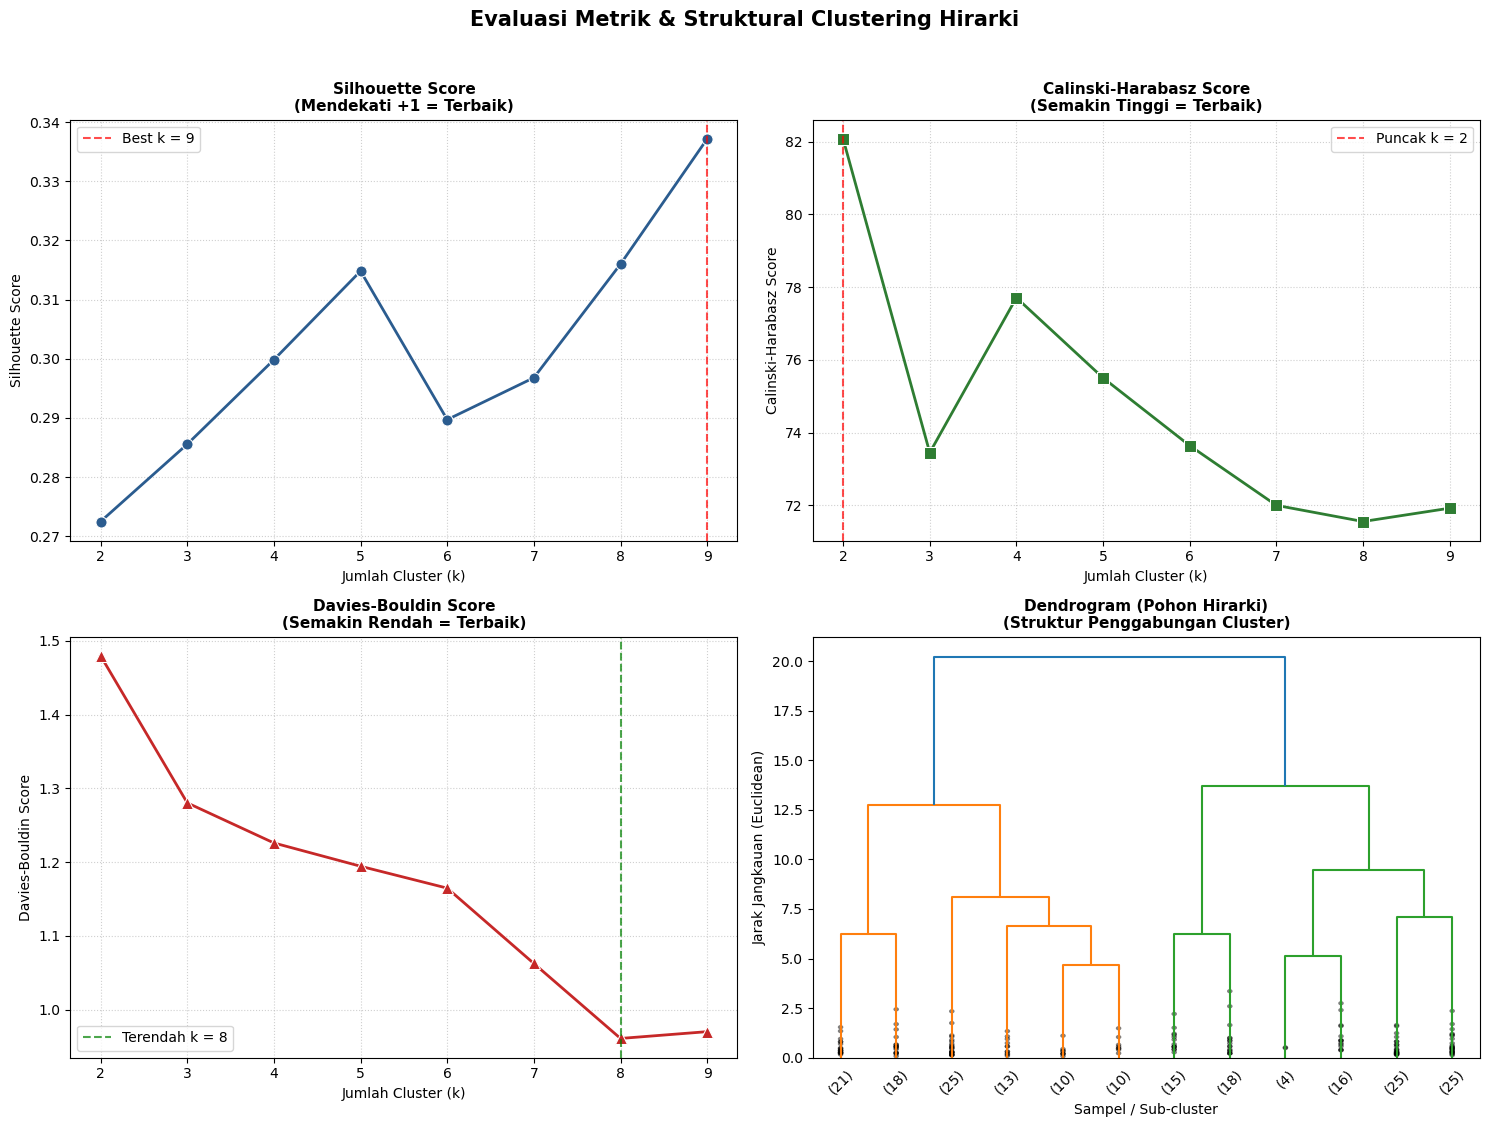

,n_clusters(k),Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
0,2,0.272482,82.080511,1.479903
1,3,0.285558,73.447807,1.280397
2,4,0.299837,77.711051,1.226044
3,5,0.314824,75.505278,1.194445
4,6,0.289707,73.640970,1.164758
5,7,0.296793,71.998393,1.062561
6,8,0.316006,71.553388,0.960897
7,9,0.337178,71.920385,0.970117


In [14]:
sil_scores = []
ch_scores = []
db_scores = []
k_range = range(2, 10)

for k in k_range:
    agl = AgglomerativeClustering(n_clusters=k,linkage='ward')
    model_agl = agl.fit_predict(X_cleaned)
    sil_scores.append(silhouette_score(X_cleaned, model_agl))
    ch_scores.append(calinski_harabasz_score(X_cleaned, model_agl))
    db_scores.append(davies_bouldin_score(X_cleaned, model_agl))

df_scores = pd.DataFrame({
    'n_clusters(k)': list(k_range),
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Silhouette Score (Mendekati +1 Lebih Baik) ---
best_k_sil = int(df_scores.loc[df_scores['Silhouette Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 0], x='n_clusters(k)', y='Silhouette Score', data=df_scores, marker='o', markersize=8, linewidth=2, color='#2b5c8f')
axes[0, 0].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Best k = {best_k_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Cluster (k)')
axes[0, 0].set_xticks(list(k_range))
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Plot 2: Calinski-Harabasz Score (Makin Tinggi Lebih Baik) ---
best_k_ch = int(df_scores.loc[df_scores['Calinski-Harabasz Score'].idxmax(), 'n_clusters(k)'])
sns.lineplot(ax=axes[0, 1], x='n_clusters(k)', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=8, linewidth=2, color='#2e7d32')
axes[0, 1].axvline(x=best_k_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak k = {best_k_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Cluster (k)')
axes[0, 1].set_xticks(list(k_range))
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Plot 3: Davies-Bouldin Score (Makin Rendah Lebih Baik) ---
best_k_db = int(df_scores.loc[df_scores['Davies-Bouldin Score'].idxmin(), 'n_clusters(k)'])
sns.lineplot(ax=axes[1, 0], x='n_clusters(k)', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=8, linewidth=2, color='#c62828')
axes[1, 0].axvline(x=best_k_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah k = {best_k_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Cluster (k)')
axes[1, 0].set_xticks(list(k_range))
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Plot 4: Dendrogram Visualisasi Hirarki ---
Z = linkage(X_cleaned, method='ward')
dendrogram(Z, ax=axes[1, 1], truncate_mode='lastp', p=12, leaf_rotation=45, leaf_font_size=10, show_contracted=True)
axes[1, 1].set_title('Dendrogram (Pohon Hirarki)\n(Struktur Penggabungan Cluster)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Sampel / Sub-cluster')
axes[1, 1].set_ylabel('Jarak Jangkauan (Euclidean)')
axes[1, 1].grid(False)

plt.suptitle('Evaluasi Metrik & Struktural Clustering Hirarki', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Menampilkan DataFrame hasil evaluasi
df_scores

In [16]:
n_cluster = 2
best_agl= AgglomerativeClustering(n_clusters=2,linkage='ward')
df['Cluster'] = best_agl.fit_predict(X_cleaned)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,0
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,0
